# **Machine Learning II | <span style="color: steelblue;">Segmentation</span>**

## A Clustering-Based Exploration of WorkplaceAbsence Patterns

*Group 07*

*Group members* : Francisco Gomes (20221810), Margarida Marchão (20221901), Pedro Coimbras (20211573) and Marta Alves (20221890).

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px
from pylab import rcParams
rcParams['figure.figsize'] = 30, 15
import umap

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from tqdm.notebook import tqdm, trange
tqdm.pandas(desc="Progress")

import warnings
from modeling_pipeline import(
    compare_cluster_solutions,
    calculate_group_means,
    create_dendrogram,
    visualize_inertia_silhouette,
    plot_dimensionality_reduction_results,
    check_for_karens,
    plot_cluster_by_coordinates,
    plot_r2_hc
)
warnings.filterwarnings('ignore', category = FutureWarning)
pd.set_option('display.max_columns', None)

In [4]:
worker = pd.read_csv('Processed Absenteeism Dataset.csv')
display(worker.head())

,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Age,Education,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,bmi_category,Absenteeism time in hours_count,Absenteeism time in hours_sum,Absenteeism time in hours_mean,Disciplinary failure_sum,Reason_Certain conditions originating in the perinatal period_sum,Reason_Certain infectious and parasitic diseases_sum,"Reason_Congenital malformations, deformations and chromosomal abnormalities_sum",Reason_Dental consultation_sum,Reason_Diseases of the blood and blood-forming organs and immune mechanism_sum,Reason_Diseases of the circulatory system_sum,Reason_Diseases of the digestive system_sum,Reason_Diseases of the ear and mastoid process_sum,Reason_Diseases of the eye and adnexa_sum,Reason_Diseases of the genitourinary system_sum,Reason_Diseases of the musculoskeletal system and connective tissue_sum,Reason_Diseases of the nervous system_sum,Reason_Diseases of the respiratory system_sum,Reason_Diseases of the skin and subcutaneous tissue_sum,"Reason_Endocrine, nutritional and metabolic diseases_sum",Reason_Factors influencing health status and contact with health services_sum,"Reason_Injury, poisoning and other consequences of external causes_sum",Reason_Laboratory examination_sum,Reason_Medical consultation_sum,Reason_Mental and behavioural disorders_sum,Reason_Neoplasms_sum,Reason_Patient follow-up_sum,Reason_Physiotherapy_sum,"Reason_Pregnancy, childbirth and the puerperium_sum","Reason_Symptoms, signs and abnormal clinical and laboratory findings_sum",Reason_Unjustified absence_sum,Reason_Unspecified_sum
0,235,11,14.0,28.0,37,Postgraduate,1,0,0,1,88.0,172,Overweight,24,122.0,5.083333,1,0,1,0,0,0,0,1,0,1,1,3,0,0,0,0,1,1,2,5,0,0,4,0,0,1,2,1
1,235,29,12.0,17.0,48,High School,1,0,1,5,88.0,163,Obesity Class I,6,25.0,4.166667,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,2
2,179,51,18.0,27.0,38,High School,0,1,0,0,89.0,170,Obesity Class I,122,501.0,4.106557,2,0,0,0,26,0,0,7,0,0,0,10,1,2,1,0,2,0,2,28,1,0,0,38,0,2,1,1
3,118,14,13.0,25.0,40,High School,1,1,0,8,98.0,170,Obesity Class I,1,0.0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,235,20,13.0,22.0,43,High School,1,1,0,0,106.0,167,Obesity Class II,20,112.0,5.600000,5,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,0,3,0,0,0,0,0,0,9,5


In [5]:
np.unique(worker['Education'], return_counts=True)

(array(['Graduate', 'High School', 'Postgraduate'], dtype=object),
 array([ 4, 29,  3]))

In [6]:
# One-hot encode the categorical column
worker= pd.get_dummies(worker, columns=['Education'], drop_first=True)
worker = pd.get_dummies(worker, columns=['bmi_category'], drop_first=True)


In [12]:
worker.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 49 columns):
 #   Column                                                                           Non-Null Count  Dtype  
---  ------                                                                           --------------  -----  
 0   Transportation expense                                                           36 non-null     int64  
 1   Distance from Residence to Work                                                  36 non-null     int64  
 2   Service time                                                                     36 non-null     float64
 3   Years until retirement                                                           36 non-null     float64
 4   Age                                                                              36 non-null     int64  
 5   Number of children                                                               36 non-null     int64  
 6   Social drink

# **Scaling**

In [7]:
worker_no_scl = worker.copy()
worker_st_scl = StandardScaler().fit_transform(worker)
worker_mm_scl = MinMaxScaler().fit_transform(worker)
worker_rb_scl = RobustScaler().fit_transform(worker)

# **Clustering**

In the notebook, the cluster analysis is grouped by data inputs: no scaling,standard scaler, minmax scaler, and robust scaler. In each group, the following methods of clustering were used and are presented in this order:

1. KMeans
2. Ward (Hierarchical)

Given that the Ward method consistently outperforms the other methods in terms of the R2 metric across all cluster numbers, it is justifiable to focus on analyzing the Ward method for hierarchical clustering in this context. The Ward method provides a superior explanation of the variance within the data, making it the most reliable choice for this analysis.

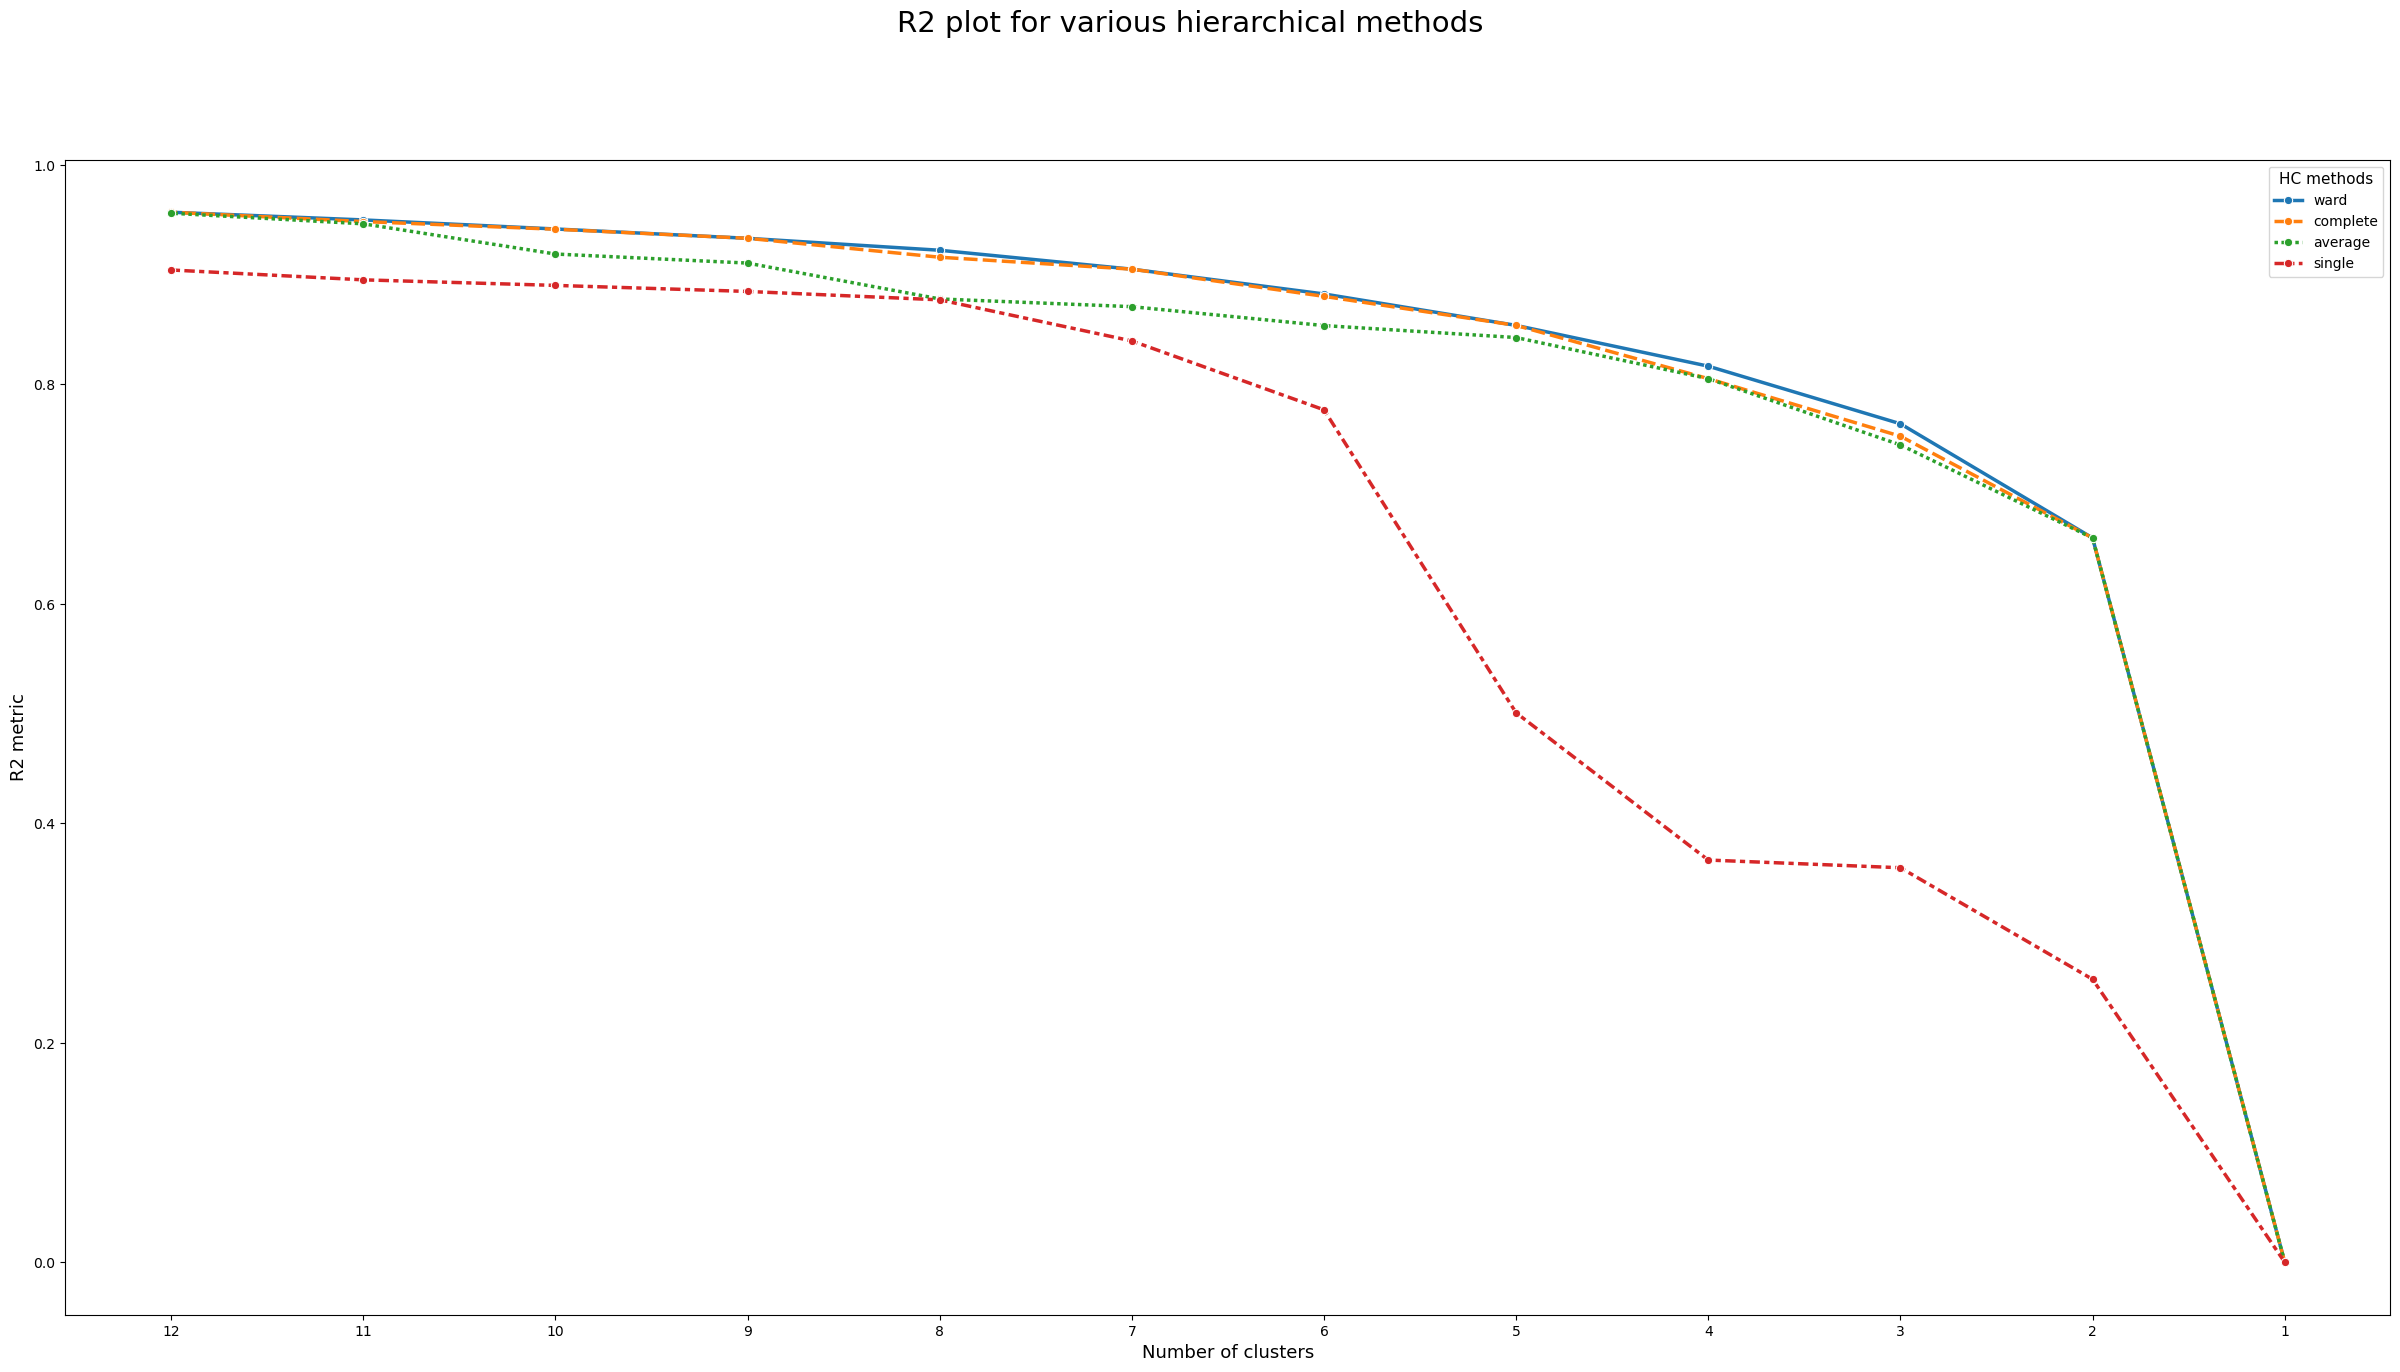

In [8]:
plot_r2_hc(worker_no_scl, max_nclus=12)

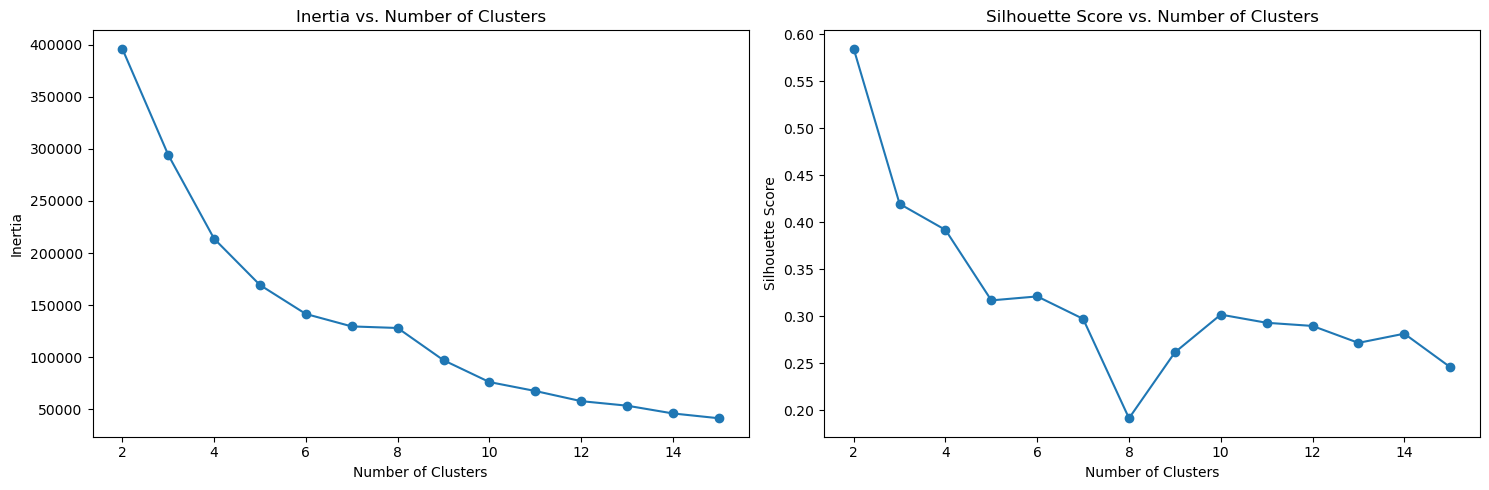

In [9]:
visualize_inertia_silhouette(worker_no_scl)

In [10]:
kmeans = KMeans(n_clusters = 6, random_state = 0).fit(worker_no_scl)
worker['no_kmeans6'] = kmeans.predict(worker_no_scl)

kmeans = KMeans(n_clusters = 8, random_state = 0).fit(worker_no_scl)
worker['no_kmeans8'] = kmeans.predict(worker_no_scl)

In [11]:
compare_cluster_solutions(worker, 'no_kmeans6', 'no_kmeans8')

,no_kmeans8 Cluster 0,no_kmeans8 Cluster 1,no_kmeans8 Cluster 2,no_kmeans8 Cluster 3,no_kmeans8 Cluster 4,no_kmeans8 Cluster 5,no_kmeans8 Cluster 6,no_kmeans8 Cluster 7
no_kmeans6 Cluster 0,4,0,0,2,0,0,0,0
no_kmeans6 Cluster 1,0,9,0,0,3,6,0,3
no_kmeans6 Cluster 2,0,0,0,0,0,0,2,0
no_kmeans6 Cluster 3,0,0,0,2,0,0,0,1
no_kmeans6 Cluster 4,0,0,0,1,1,0,0,0
no_kmeans6 Cluster 5,0,0,2,0,0,0,0,0
